# Stats_chat_analysis — Descriptive statistics & visualizations

This notebook loads the processed dataset (`corpus.csv`) created in `ChatAnalysis.ipynb` and produces descriptive statistics and plots.

## What this notebook does
- Computes high-level totals (messages, tokens).
- Compares participants:
  - total messages per person
  - average tokens per message per person
- Explores time trends:
  - messages per month over the full timeline
  - messages per month per person over the full timeline
- Text exploration per person:
  - most frequent words with stopword removal

## Input
- `corpus.csv`

## Output
- Plots displayed inline (and optionally saved).

In [34]:
# Import the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from spacy.lang.nl.stop_words import STOP_WORDS as NL_STOPWORDS

In [51]:
# Folder to save plots
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

def save_plot(filename):
    """Save the current matplotlib figure into the plots folder."""
    plt.gcf().savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

In [52]:
# Load the processed chat dataset (exported from ChatAnalysis.ipynb)
from pathlib import Path
data_path = Path("corpus.csv")
df = pd.read_csv(data_path)

In [53]:
# Convert the Date column (stored as text) into a proper datetime colum
df["Date_dt"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")

df.head(10)

,Message_ID,Person,Date,Time,Doc,Tokens,Lemmas,POS,Date_dt
0,1,BM,19-01-2020,00:08,Aangezien ik Leon en Martijn (rima) nog nooit ...,"['Aangezien', 'ik', 'Leon', 'en', 'Martijn', '...","['aangezien', 'ik', 'Leon', 'en', 'Martijn', '...","[('SCONJ', 'VG|onder'), ('PRON', 'VNW|pers|pro...",2020-01-19
1,2,SM,19-01-2020,00:11,Omg leuk! Ik kom alleen als Cait goed geschrev...,"['Omg', 'leuk', '!', 'Ik', 'kom', 'alleen', 'a...","['Omg', 'leuk', '!', 'ik', 'komen', 'alleen', ...","[('PRON', 'N|soort|ev|basis|zijd|stan'), ('ADJ...",2020-01-19
2,3,DK,19-01-2020,00:14,Leuk idee!,"['Leuk', 'idee', '!']","['leuk', 'idee', '!']","[('ADJ', 'ADJ|prenom|basis|zonder'), ('NOUN', ...",2020-01-19
3,4,BM,19-01-2020,00:28,HAHAHAHAHAHA oeps,"['HAHAHAHAHAHA', 'oeps']","['HAHAHAHAHAHA', 'oeps']","[('PROPN', 'N|eigen|ev|basis|genus|stan'), ('V...",2020-01-19
4,5,BM,19-01-2020,00:28,Ho,['Ho'],['ho'],"[('DET', 'TSW')]",2020-01-19
5,6,BM,19-01-2020,00:28,Hahahahaha,['Hahahahaha'],['Hahahahaha'],"[('PROPN', 'N|eigen|ev|basis|onz|stan')]",2020-01-19
6,7,BM,19-01-2020,11:02,"Hans, hoe voel je je vandaag?","['Hans', ',', 'hoe', 'voel', 'je', 'je', 'vand...","['Hans', ',', 'hoe', 'voelen', 'je', 'je', 'va...","[('PROPN', 'N|eigen|ev|basis|zijd|stan'), ('PU...",2020-01-19
7,8,HW,19-01-2020,11:31,Lief dat je het vraagt! Het gaat redelijk haha...,"['Lief', 'dat', 'je', 'het', 'vraagt', '!', 'H...","['lief', 'dat', 'je', 'het', 'vragen', '!', 'h...","[('ADJ', 'ADJ|vrij|basis|zonder'), ('SCONJ', '...",2020-01-19
8,9,BM,19-01-2020,11:51,Geloof graag dat alles nu heel beurs is! Geluk...,"['Geloof', 'graag', 'dat', 'alles', 'nu', 'hee...","['Geloof', 'graag', 'dat', 'alles', 'nu', 'hee...","[('NOUN', 'N|soort|ev|basis|onz|stan'), ('ADV'...",2020-01-19
9,10,HW,19-01-2020,15:17,Ja precies!,"['Ja', 'precies', '!']","['ja', 'precies', '!']","[('INTJ', 'TSW'), ('ADJ', 'ADJ|vrij|basis|zond...",2020-01-19


In [54]:
# Total number of messages in the dataset
total_messages = len(df)
total_messages

31373

In [55]:
# Estimate the total number of tokens in the dataset
total_tokens = df["Tokens"].apply(lambda x: len(str(x).split())).sum()
total_tokens

np.int64(265952)

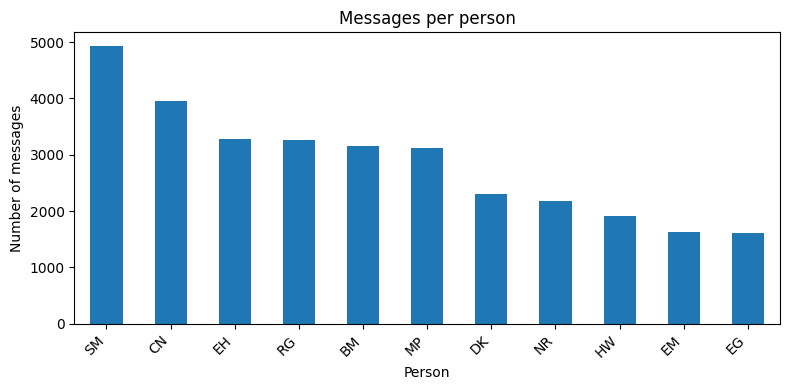

In [56]:
# Count how many messages each person sent
messages_per_person = df["Person"].value_counts().sort_values(ascending=False)
messages_per_person

# Bar chart: messages per person
plt.figure(figsize=(8, 4))
messages_per_person.plot(kind="bar")
plt.title("Messages per person")
plt.xlabel("Person")
plt.ylabel("Number of messages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_plot("messages_per_person.png")
plt.show()

In [57]:
df["token_count"] = df["Tokens"].apply(lambda x: len(str(x).split()))

In [58]:
# Compute the average number of tokens per message for each person
avg_tokens_per_person = df.groupby("Person")["token_count"].mean().sort_values(ascending=False)

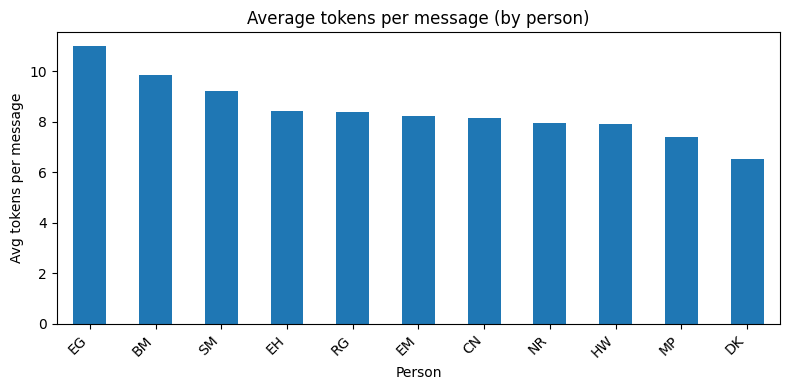

In [59]:
# Bar chart: avg tokens per message per person
plt.figure(figsize=(8, 4))
avg_tokens_per_person.plot(kind="bar")
plt.title("Average tokens per message (by person)")
plt.xlabel("Person")
plt.ylabel("Avg tokens per message")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_plot("avg_tokens_per_person.png")
plt.show()

In [60]:
# Group messages by month to see how activity changes over time
monthly_messages = (
    df.dropna(subset=["Date_dt"])
      .assign(Month=lambda x: x["Date_dt"].dt.to_period("M").dt.to_timestamp())
      .groupby("Month")
      .size()
      .sort_index()
)

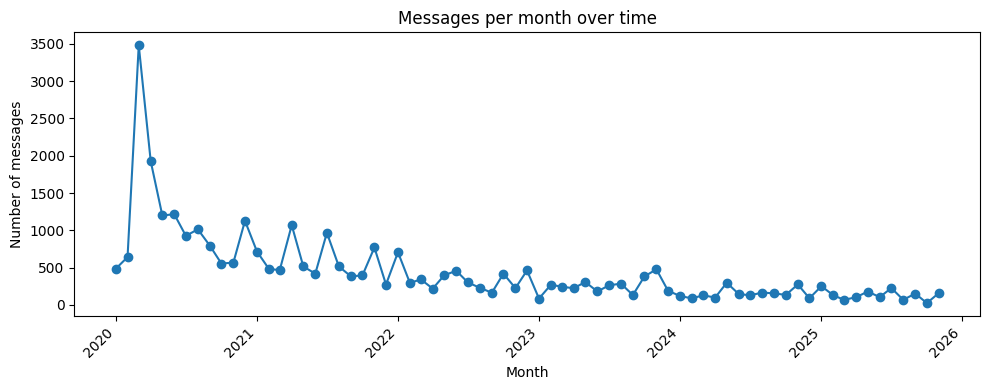

In [61]:
# Line plot: messages per month
plt.figure(figsize=(10, 4))
plt.plot(monthly_messages.index, monthly_messages.values, marker="o")
plt.title("Messages per month over time")
plt.xlabel("Month")
plt.ylabel("Number of messages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_plot("messages_per_month.png")
plt.show()

In [62]:
# Create a table of monthly message counts per person
monthly_by_person = (
    df.dropna(subset=["Date_dt"])
      .assign(Month=lambda x: x["Date_dt"].dt.to_period("M").dt.to_timestamp())
      .groupby(["Month", "Person"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

monthly_by_person.head()

Person,BM,CN,DK,EG,EH,EM,HW,MP,NR,RG,SM
Month,,,,,,,,,,,
2020-01-01,56,51,50,26,38,17,105,27,24,43,44
2020-02-01,72,84,55,15,48,21,54,77,38,79,97
2020-03-01,367,439,537,143,496,198,93,271,74,457,408
2020-04-01,182,157,184,76,217,84,150,200,121,189,366
2020-05-01,123,123,82,50,179,43,43,89,89,159,219


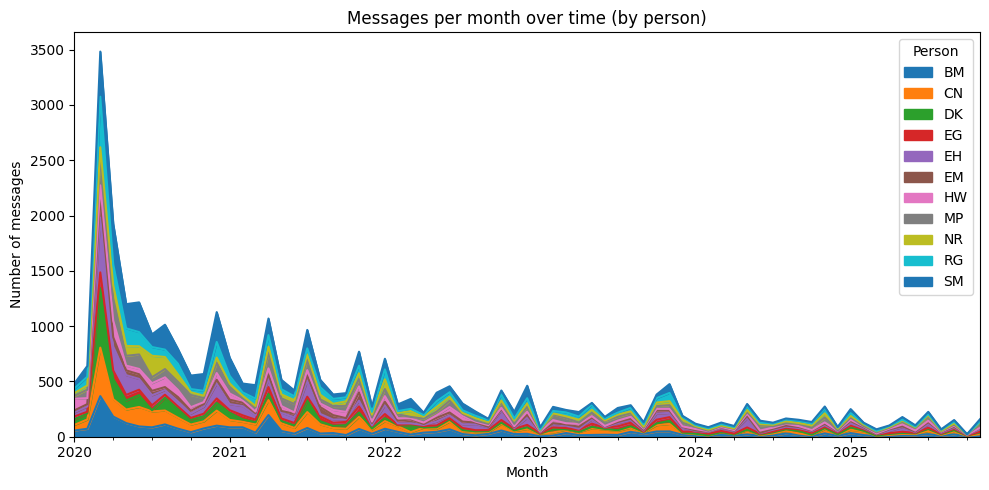

In [63]:
# stacked area plot: messages per month per person
monthly_by_person.plot(kind="area", stacked=True, figsize=(10, 5))
plt.title("Messages per month over time (by person)")
plt.xlabel("Month")
plt.ylabel("Number of messages")
plt.tight_layout()

save_plot("messages_per_month_by_person.png")
plt.show()

In [64]:
from spacy.lang.nl.stop_words import STOP_WORDS as NL_STOPWORDS

# Define a cleaning function for words extracted from the Doc column: lowercase, remove stopwords, keep only alphabetic tokens, remove short tokens
def clean_words_from_docs(docs):
    words = []
    for doc in docs:
        if not isinstance(doc, str):
            continue
        for w in doc.split():
            w = w.lower()
            if w in NL_STOPWORDS:
                continue
            if not w.isalpha():
                continue
            if len(w) <= 2:
                continue
            words.append(w)
    return words

all_words = clean_words_from_docs(df["Doc"])
most_common_words = Counter(all_words).most_common(30)

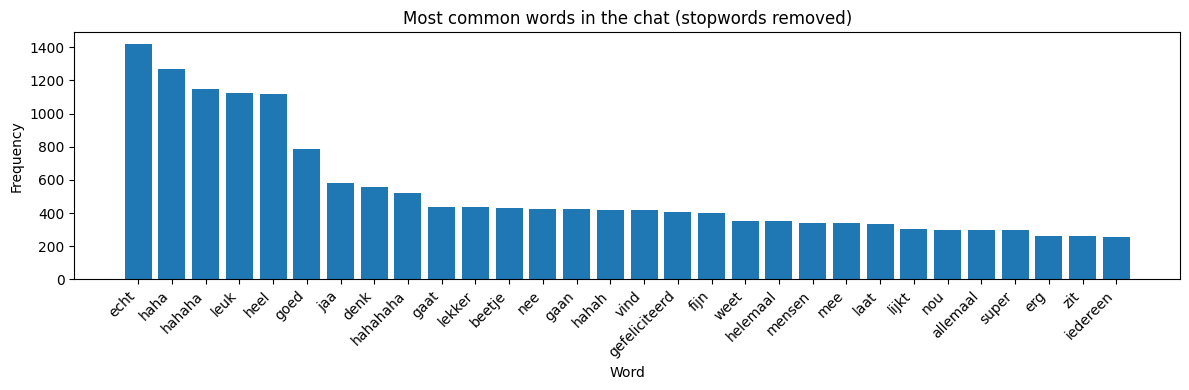

In [65]:
# Plot the top 30 most common words overall
words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 4))
plt.bar(words, counts)
plt.title("Most common words in the chat (stopwords removed)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_plot("most_common_words_overall.png")
plt.show()

In [66]:
# For each person, collect their cleaned words and print the top N
top_n = 10
for person, sub in df.groupby("Person"):
    person_words = clean_words_from_docs(sub["Doc"])
    most_common = Counter(person_words).most_common(top_n)
    print(person, most_common[:10])


BM [('jaa', 218), ('hahah', 209), ('echt', 205), ('heel', 179), ('hahaha', 158), ('goed', 112), ('leuk', 80), ('hahahah', 69), ('vind', 65), ('gefeliciteerd', 62)]
CN [('haha', 379), ('echt', 187), ('leuk', 172), ('hahaha', 109), ('goed', 99), ('denk', 89), ('heel', 88), ('super', 77), ('gaat', 76), ('mensen', 68)]
DK [('echt', 189), ('heel', 93), ('leuk', 82), ('hahahaha', 61), ('harte', 58), ('hahaha', 48), ('goed', 43), ('san', 42), ('vind', 37), ('nee', 35)]
EG [('leuk', 99), ('heel', 69), ('gefeliciteerd', 69), ('goed', 54), ('super', 48), ('hee', 44), ('denk', 42), ('haha', 39), ('fijn', 38), ('laat', 36)]
EH [('hahaha', 122), ('jaa', 109), ('heel', 102), ('echt', 97), ('leuk', 90), ('haha', 89), ('hahahaha', 78), ('beetje', 74), ('nee', 62), ('goed', 59)]
EM [('heel', 95), ('echt', 86), ('hahaha', 84), ('haha', 78), ('leuk', 59), ('goed', 57), ('nee', 38), ('gefeliciteerd', 38), ('gaat', 34), ('lijkt', 32)]
HW [('echt', 101), ('leuk', 84), ('hahaha', 81), ('hahahaha', 81), ('hee

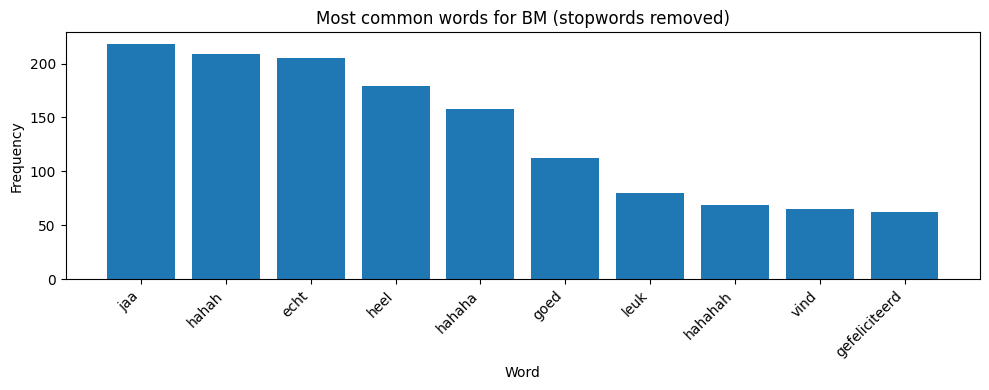

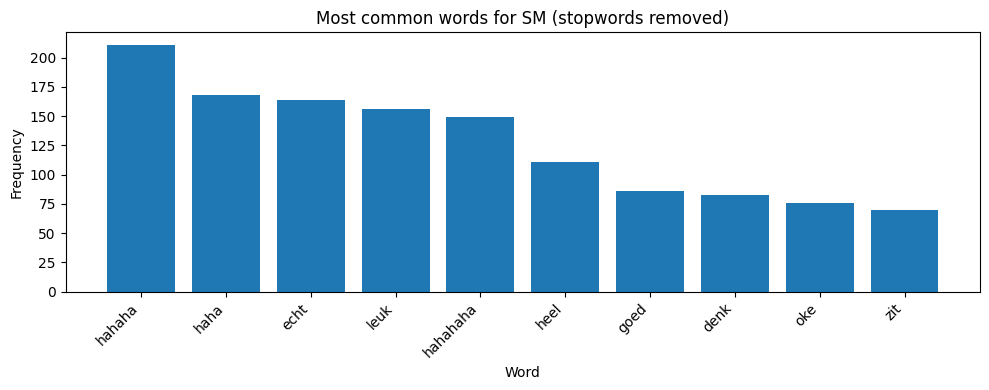

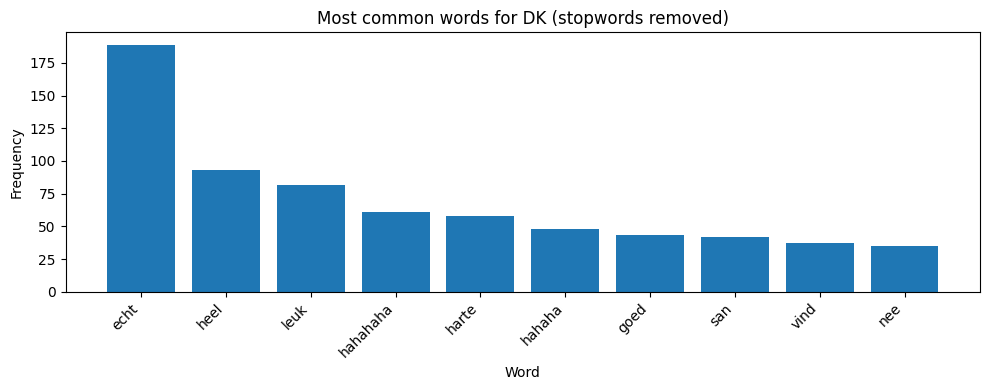

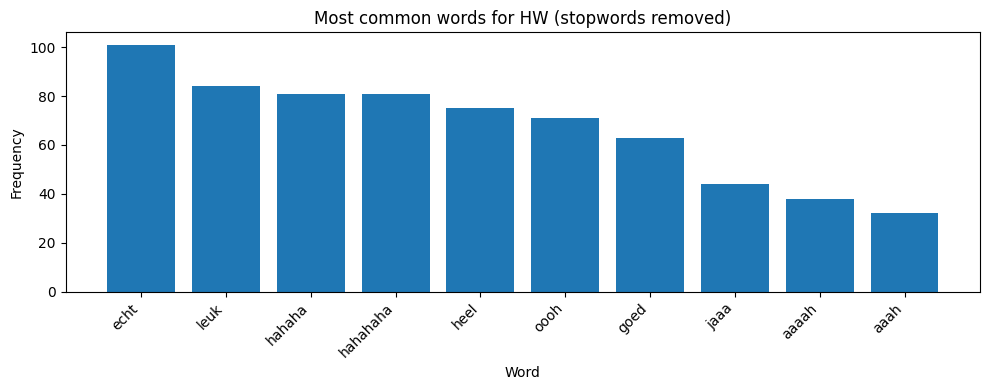

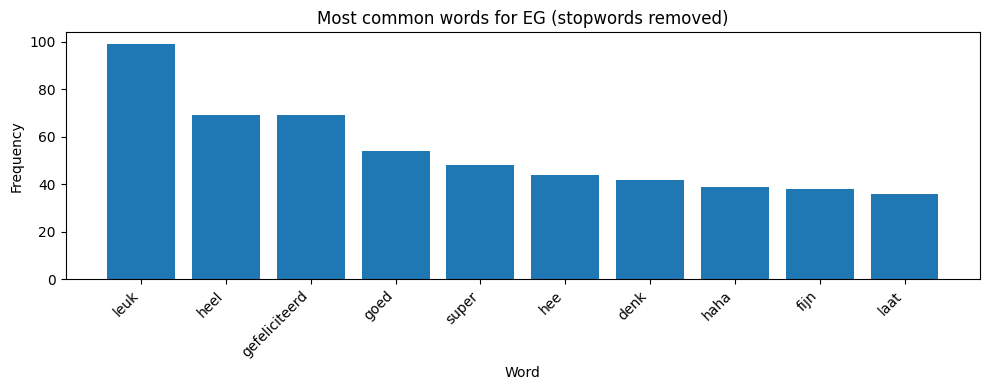

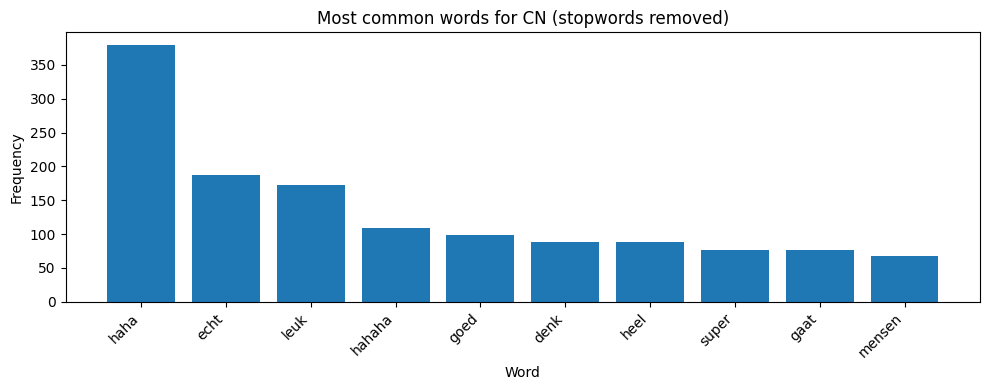

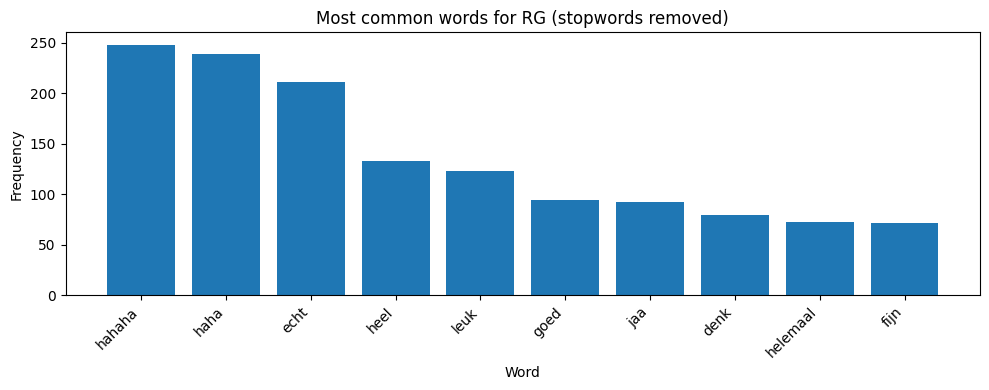

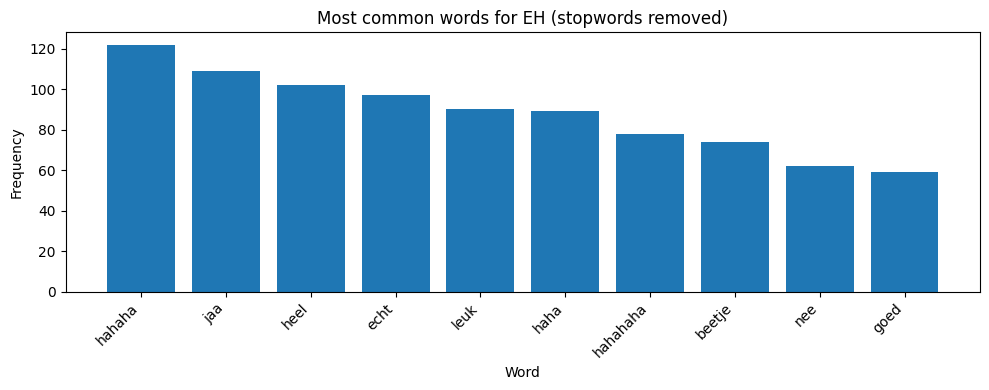

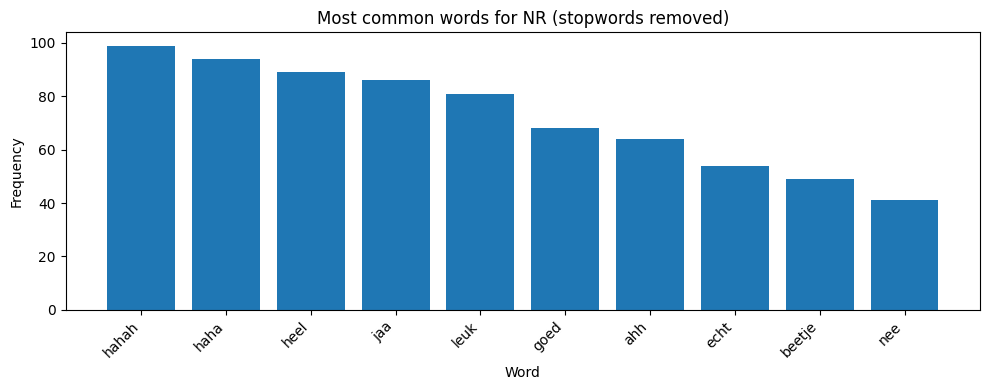

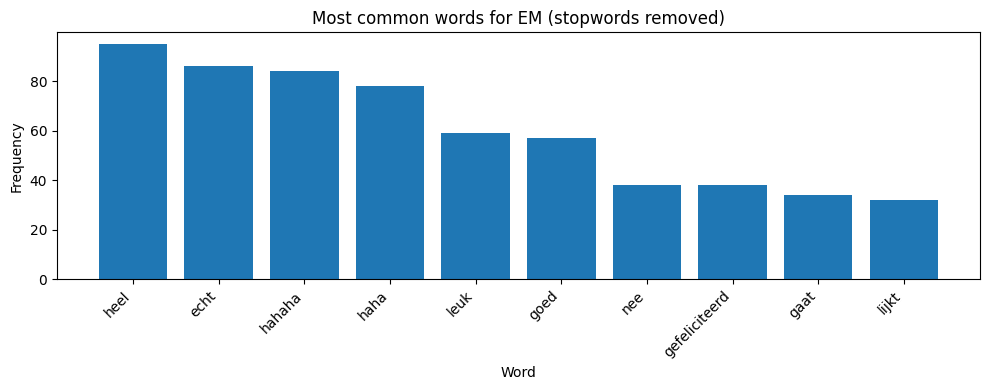

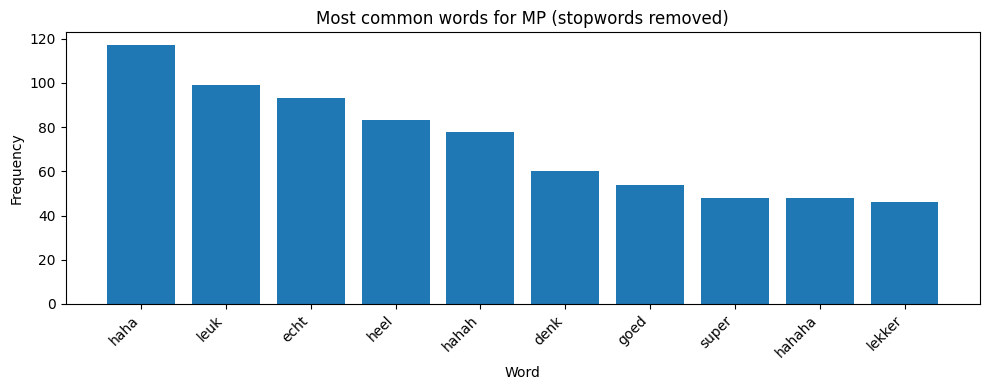

In [67]:
# Visualise the most common words for each person as a bar chart
top_n = 10

for person in df["Person"].unique():
    person_words = []
    person_df = df[df["Person"] == person]

    for doc in person_df["Doc"]:
        if not isinstance(doc, str):
            continue

        for word in doc.split():
            word = word.lower()

            if word in NL_STOPWORDS:
                continue
            if not word.isalpha():
                continue
            if len(word) <= 2:
                continue

            person_words.append(word)

    most_common = Counter(person_words).most_common(top_n)

    if not most_common:
        continue

    words, counts = zip(*most_common)

    plt.figure(figsize=(10, 4))
    plt.bar(words, counts)
    plt.title(f"Most common words for {person} (stopwords removed)")
    plt.xlabel("Word")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    save_plot(f"most_common_words_{person}.png")
    plt.show()